# Actividad 2 — Análisis exploratorio inicial
**Reto StayData Lab · base *Airbnb price prediction***

Este notebook es deliberadamente delgado: toda la lógica vive en el paquete
`staydata_eda` (arquitectura por capas), y aquí solo se orquesta y se muestran
resultados. Así el mismo código corre desde el notebook, desde la CLI
(`python -m staydata_eda.main`) y dentro del contenedor Docker.

| Capa | Contenido |
|---|---|
| `domain` | entidades, puertos (interfaces) y el esquema de columnas |
| `application` | casos de uso, perfilado y reglas de calidad |
| `infrastructure` | lectura del archivo, configuración y gráficas |

**Importante:** esta actividad *no* limpia ni transforma la base. Solo describe.
La limpieza formal corresponde a la Actividad 3.

## 1. Configuración y wiring de dependencias

In [1]:
import sys
from pathlib import Path

# Make the package importable when the notebook runs from the notebooks/ folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import pandas as pd

from staydata_eda.container import build_analysis, configure_logging
from staydata_eda.application.profiling import to_frame
from staydata_eda.domain import schema

configure_logging()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

# The composition root wires repository + rules + renderer together.
analysis = build_analysis()
print("Proyecto:", PROJECT_ROOT)

Proyecto: /home/claude/staydata-airbnb-eda


## 2. Carga de datos

El archivo original **no se modifica**. El repositorio lo lee en modo lectura y
reconstruye la tabla: el workbook trae todo el CSV dentro de una sola columna y
los registros largos se derraman en columnas adicionales por el límite de 32,767
caracteres por celda de Excel.

In [2]:
listings = analysis.load()
print(f"Filas: {listings.shape[0]:,}   Columnas: {listings.shape[1]}")
print("Registros descartados por comillas mal cerradas:", listings.attrs.get("malformed_records"))

17:41:55 | INFO    | staydata_eda.application.use_cases | Loading data from Excel workbook 'airbnb_price_prediction.xlsx' (sheet 'in') cached at 'listings.parquet'


17:41:55 | INFO    | staydata_eda.infrastructure.repositories | Loading cached table from /home/claude/staydata-airbnb-eda/data/interim/listings.parquet


Filas: 74,080   Columnas: 30
Registros descartados por comillas mal cerradas: 19


## 3. Estructura general: tipos, nombres y primeras observaciones

In [3]:
listings.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 74080 entries, 0 to 74079
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   id                      74080 non-null  str           
 1   log_price               74080 non-null  float64       
 2   property_type           74080 non-null  str           
 3   room_type               74080 non-null  str           
 4   amenities               74080 non-null  str           
 5   accommodates            74080 non-null  int64         
 6   bathrooms               73881 non-null  float64       
 7   bed_type                74080 non-null  str           
 8   cancellation_policy     74080 non-null  str           
 9   cleaning_fee            74080 non-null  str           
 10  city                    74080 non-null  str           
 11  description             74080 non-null  str           
 12  first_review            58224 non-null  datetime64[us]
 1

In [4]:
listings.head(3)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds,price_usd
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0,150.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0,169.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0,145.0


In [5]:
listings.tail(3)

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds,price_usd
74077,18688039,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,moderate,True,NYC,A modern apartment located in East Williamsbur...,2015-01-03,t,t,100%,2012-01-05,t,2017-09-10,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,Williamsburg,43,94.0,https://a0.muscache.com/im/pictures/7fbe448c-5...,11206.0,2.0,2.0,185.0
74078,17045948,5.273000,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,strict,True,NYC,"Fully renovated, designer's studio located in ...",NaT,t,f,100%,2017-09-17,t,NaT,40.738535,-74.000157,Designer's Apartment in HEART of NYC,West Village,0,NaN,https://a0.muscache.com/im/pictures/b3971b63-0...,10011,0.0,2.0,195.0
74079,3534845,4.852030,Boat,Entire home/apt,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",4,1.0,Real Bed,moderate,False,LA,You will stay-aboard the Island Trader at one ...,2013-09-05,t,t,100%,2012-11-26,f,2017-04-30,33.761096,-118.192409,Cozy Boat at Shoreline Village,Long Beach,205,96.0,https://a0.muscache.com/im/pictures/22968537/d...,90802,1.0,2.0,128.0


In [6]:
from staydata_eda.application.profiling import profile_dataset

profile = profile_dataset(listings)
print(f"{profile.rows:,} filas x {profile.columns} columnas")
print(f"ids duplicados: {profile.duplicated_ids} | filas idénticas: {profile.duplicated_rows}")

structure = to_frame(profile.column_profiles)
structure[["name", "dtype", "non_null", "missing", "missing_pct", "unique"]]

74,080 filas x 30 columnas
ids duplicados: 0 | filas idénticas: 0


,name,dtype,non_null,missing,missing_pct,unique
0,id,str,74080,0,0.00,74080
1,log_price,float64,74080,0,0.00,767
2,property_type,str,74080,0,0.00,35
3,room_type,str,74080,0,0.00,3
4,amenities,str,74080,0,0.00,67096
5,accommodates,int64,74080,0,0.00,16
6,bathrooms,float64,73881,199,0.27,17
7,bed_type,str,74080,0,0.00,5
8,cancellation_policy,str,74080,0,0.00,5
9,cleaning_fee,str,74080,0,0.00,2


## 4. Consultas básicas

Nombres de columnas, valores únicos de las categóricas relevantes y un vistazo
a los grupos analíticos definidos en la Actividad 1.

In [7]:
print("Columnas disponibles:")
print(list(listings.columns))

Columnas disponibles:
['id', 'log_price', 'property_type', 'room_type', 'amenities', 'accommodates', 'bathrooms', 'bed_type', 'cancellation_policy', 'cleaning_fee', 'city', 'description', 'first_review', 'host_has_profile_pic', 'host_identity_verified', 'host_response_rate', 'host_since', 'instant_bookable', 'last_review', 'latitude', 'longitude', 'name', 'neighbourhood', 'number_of_reviews', 'review_scores_rating', 'thumbnail_url', 'zipcode', 'bedrooms', 'beds', 'price_usd']


In [8]:
for column in (schema.CITY, schema.ROOM_TYPE, schema.BED_TYPE, schema.CANCELLATION_POLICY):
    print(f"{column} ({listings[column].nunique()} valores únicos):")
    print(listings[column].value_counts().to_string(), "\n")

city (6 valores únicos):
city
NYC        32334
LA         22443
SF          6431
DC          5686
Chicago     3719
Boston      3467 

room_type (3 valores únicos):
room_type
Entire home/apt    41299
Private room       30621
Shared room         2160 

bed_type (5 valores únicos):
bed_type
Real Bed         72000
Futon              752
Pull-out Sofa      585
Airbed             476
Couch              267 

cancellation_policy (5 valores únicos):
cancellation_policy
strict             32363
flexible           22537
moderate           19051
super_strict_30      112
super_strict_60       17 



In [9]:
# Cuántos anuncios hay por ciudad y tipo de espacio (consulta cruzada básica).
pd.crosstab(listings[schema.CITY], listings[schema.ROOM_TYPE], margins=True)

room_type,Entire home/apt,Private room,Shared room,All
city,,,,
Boston,2146,1275,46,3467
Chicago,2217,1401,101,3719
DC,3882,1668,136,5686
LA,12999,8472,972,22443
NYC,16238,15289,807,32334
SF,3817,2516,98,6431
All,41299,30621,2160,74080


## 5. Estadísticas descriptivas de variables numéricas

`log_price` es la variable objetivo. Se agrega `price_usd` (exponencial de
`log_price`) únicamente como columna derivada de lectura, para poder interpretar
los números en dólares.

In [10]:
from staydata_eda.application.profiling import summarise_numeric

to_frame(summarise_numeric(listings))

,name,count,mean,std,minimum,q1,median,q3,maximum
0,log_price,74080,4.782136,0.717406,0.000000,4.317488,4.709530,5.220356,7.600402
1,accommodates,74080,3.155440,2.153742,1.000000,2.000000,2.000000,4.000000,16.000000
2,bathrooms,73881,1.235291,0.582118,0.000000,1.000000,1.000000,1.000000,8.000000
3,bedrooms,73989,1.265837,0.852207,0.000000,1.000000,1.000000,1.000000,10.000000
4,beds,73949,1.710976,1.254298,0.000000,1.000000,1.000000,2.000000,18.000000
5,number_of_reviews,74080,20.897152,37.822499,0.000000,1.000000,6.000000,23.000000,605.000000
6,review_scores_rating,57366,94.067305,7.836997,20.000000,92.000000,96.000000,100.000000,100.000000
7,latitude,74080,38.446058,3.080164,33.338905,34.127913,40.662139,40.746096,42.390437
8,longitude,74080,-92.397254,21.705068,-122.511500,-118.342393,-76.996971,-73.954658,-70.985047


In [11]:
listings[[schema.PRICE_USD]].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2)

,price_usd
count,74080.00
mean,160.38
std,168.60
min,1.00
1%,29.00
25%,75.00
50%,111.00
75%,185.00
95%,425.00
99%,987.21


In [12]:
# Correlación de Spearman contra la variable objetivo (monotónica, robusta a la asimetría).
numeric_columns = [
    schema.ACCOMMODATES, schema.BEDROOMS, schema.BEDS, schema.BATHROOMS,
    schema.NUMBER_OF_REVIEWS, schema.REVIEW_SCORES_RATING, schema.TARGET,
]
listings[numeric_columns].corr(method="spearman")[schema.TARGET].round(3).sort_values(ascending=False)

log_price               1.000
accommodates            0.589
beds                    0.481
bedrooms                0.408
bathrooms               0.283
review_scores_rating    0.085
number_of_reviews      -0.033
Name: log_price, dtype: float64

## 6. Exploración de variables categóricas

In [13]:
from staydata_eda.application.profiling import summarise_categorical

to_frame(summarise_categorical(listings))

,name,unique,top_values,missing_pct
0,city,6,"{'NYC': 32334, 'LA': 22443, 'SF': 6431, 'DC': ...",0.00
1,room_type,3,"{'Entire home/apt': 41299, 'Private room': 306...",0.00
2,property_type,35,"{'Apartment': 48981, 'House': 16505, 'Condomin...",0.00
3,bed_type,5,"{'Real Bed': 72000, 'Futon': 752, 'Pull-out So...",0.00
4,cancellation_policy,5,"{'strict': 32363, 'flexible': 22537, 'moderate...",0.00
5,cleaning_fee,2,"{'True': 54385, 'False': 19695}",0.00
6,instant_bookable,2,"{'f': 54640, 't': 19440}",0.00
7,host_identity_verified,2,"{'t': 49725, 'f': 24167}",0.25
8,host_has_profile_pic,2,"{'t': 73667, 'f': 225}",0.25
9,neighbourhood,619,"{'Williamsburg': 2861, 'Bedford-Stuyvesant': 2...",9.27


In [14]:
# Precio mediano por categoría: comparaciones descriptivas, todavía no conclusiones.
for column in (schema.ROOM_TYPE, schema.CITY, schema.CANCELLATION_POLICY, schema.INSTANT_BOOKABLE):
    grouped = listings.groupby(column)[schema.PRICE_USD].agg(["median", "size"]).sort_values("median")
    print(f"--- {column} ---")
    print(grouped.to_string(), "\n")

--- room_type ---
                 median   size
room_type                     
Shared room        45.0   2160
Private room       75.0  30621
Entire home/apt   160.0  41299 

--- city ---
         median   size
city                  
Chicago    99.0   3719
LA        100.0  22443
NYC       105.0  32334
DC        125.0   5686
Boston    136.0   3467
SF        165.0   6431 

--- cancellation_policy ---
                     median   size
cancellation_policy               
flexible               99.0  22537
moderate              105.0  19051
strict                129.0  32363
super_strict_30       250.0    112
super_strict_60       877.0     17 

--- instant_bookable ---
                  median   size
instant_bookable               
t                  105.0  19440
f                  115.0  54640 



## 7. Detección de anomalías

Cada regla es una estrategia independiente. **No se elimina ni se transforma
nada**: solo se documenta el problema y el tratamiento propuesto para después.

In [15]:
from staydata_eda.application.anomalies import AnomalyDetector

findings = AnomalyDetector.with_default_rules().detect(listings)
to_frame(findings)[["code", "title", "severity", "observed", "proposed_treatment"]]

,code,title,severity,observed,proposed_treatment
0,MISSING-HIGH,Columns with a high share of missing values,high,host_response_rate: 24.69%; review_scores_rati...,Do not drop rows. Add a 'no reviews / unknown'...
1,MISSING-MODERATE,Columns with a moderate share of missing values,medium,thumbnail_url: 11.09%; neighbourhood: 9.27%; z...,Use an 'Unknown' category for text columns and...
2,DUPLICATES,Duplicated records,low,0 repeated ids and 0 identical rows,Re-check after cleaning; no action needed if b...
3,PRICE_OUTLIERS,Extreme prices and possible upper censoring,high,160 listings at USD 20 or less (minimum USD 1)...,"Review both tails, document the apparent USD 1..."
4,ZEROS,Zero values that may be legitimate or hidden gaps,medium,bedrooms = 0 in 6713 rows; bathrooms = 0 in 19...,Treat bedrooms = 0 as a studio flag; review ze...
5,FORMATS-ZIP,Inconsistent postal code format,medium,8875 values do not match a 5-digit pattern (e....,Normalise to five digits before using it as a ...
6,FORMATS-BOOL,Numeric and boolean values stored as text,medium,host_response_rate keeps the '%' sign; cleanin...,Convert the rate to a decimal and unify boolea...
7,CARDINALITY,High-cardinality categorical variables,medium,neighbourhood: 619 levels; zipcode: 767 levels...,Group rare levels into 'Other' and use frequen...
8,TEXT,Unstructured text pending extraction,medium,amenities holds 17.6 items on average and 585 ...,Turn the most frequent amenities into binary i...


## 8. Visualizaciones exploratorias

Cinco figuras se guardan en `reports/figures/`. La interpretación de cada una
está en el reporte escrito que acompaña a esta entrega.

In [16]:
report = analysis.execute(listings)
for path in report.figures:
    print(path)

17:42:00 | INFO    | staydata_eda.infrastructure.plotting | Rendering fig1_price_distribution.png


17:42:01 | INFO    | staydata_eda.infrastructure.plotting | Rendering fig2_price_by_room_type.png


17:42:01 | INFO    | staydata_eda.infrastructure.plotting | Rendering fig3_price_vs_accommodates.png


17:42:02 | INFO    | staydata_eda.infrastructure.plotting | Rendering fig4_price_by_city.png


17:42:02 | INFO    | staydata_eda.infrastructure.plotting | Rendering fig5_missing_values.png


17:42:02 | INFO    | staydata_eda.application.use_cases | Exploration finished: 74080 rows, 9 findings, 5 figures


/home/claude/staydata-airbnb-eda/reports/figures/fig1_price_distribution.png
/home/claude/staydata-airbnb-eda/reports/figures/fig2_price_by_room_type.png
/home/claude/staydata-airbnb-eda/reports/figures/fig3_price_vs_accommodates.png
/home/claude/staydata-airbnb-eda/reports/figures/fig4_price_by_city.png
/home/claude/staydata-airbnb-eda/reports/figures/fig5_missing_values.png


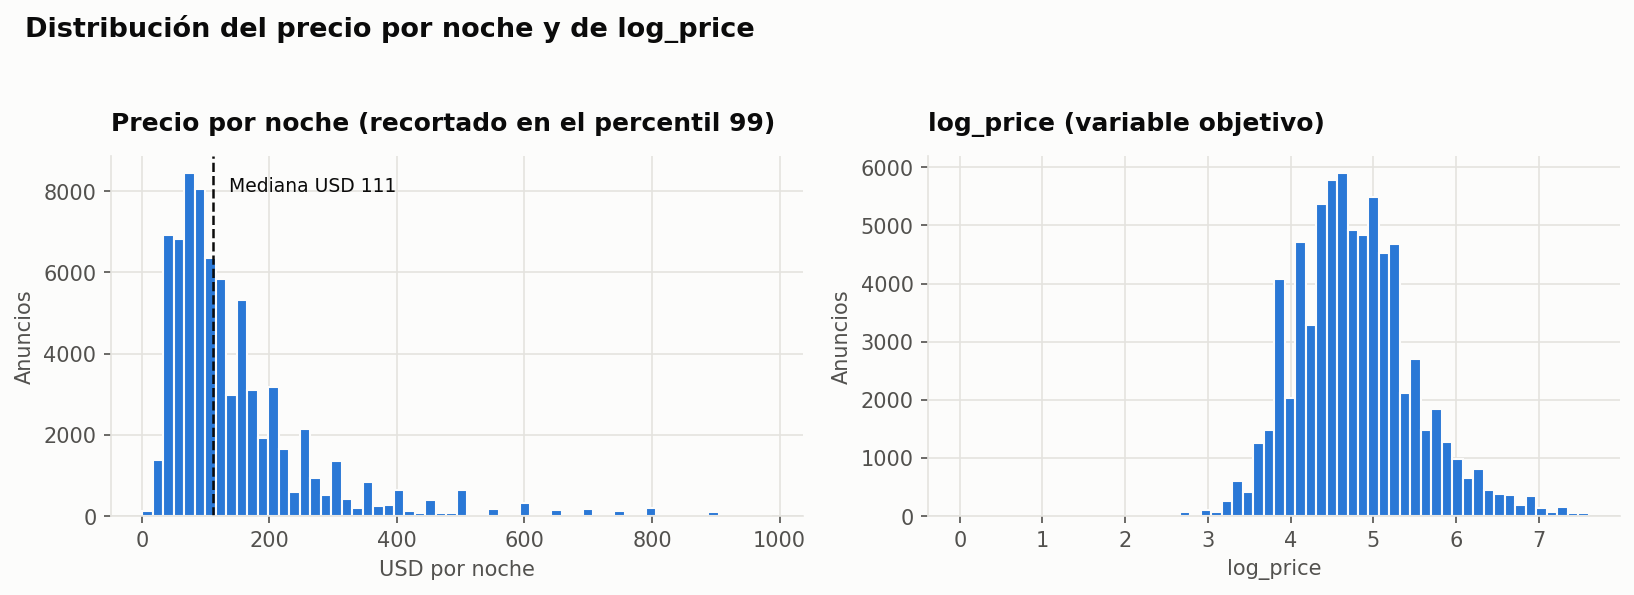

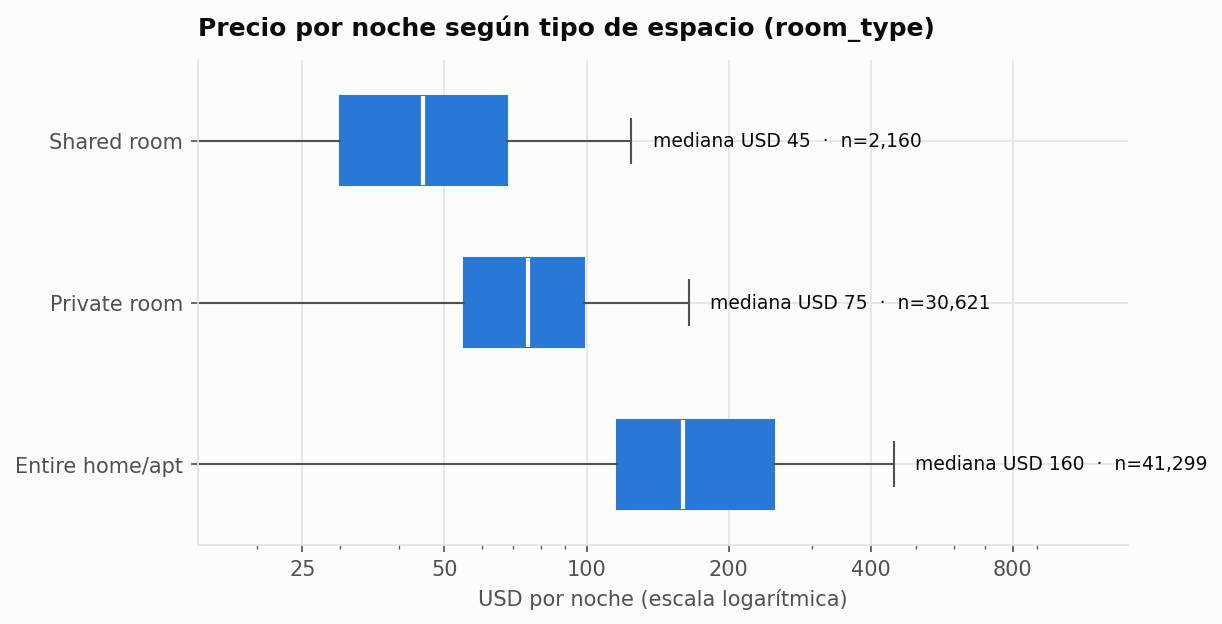

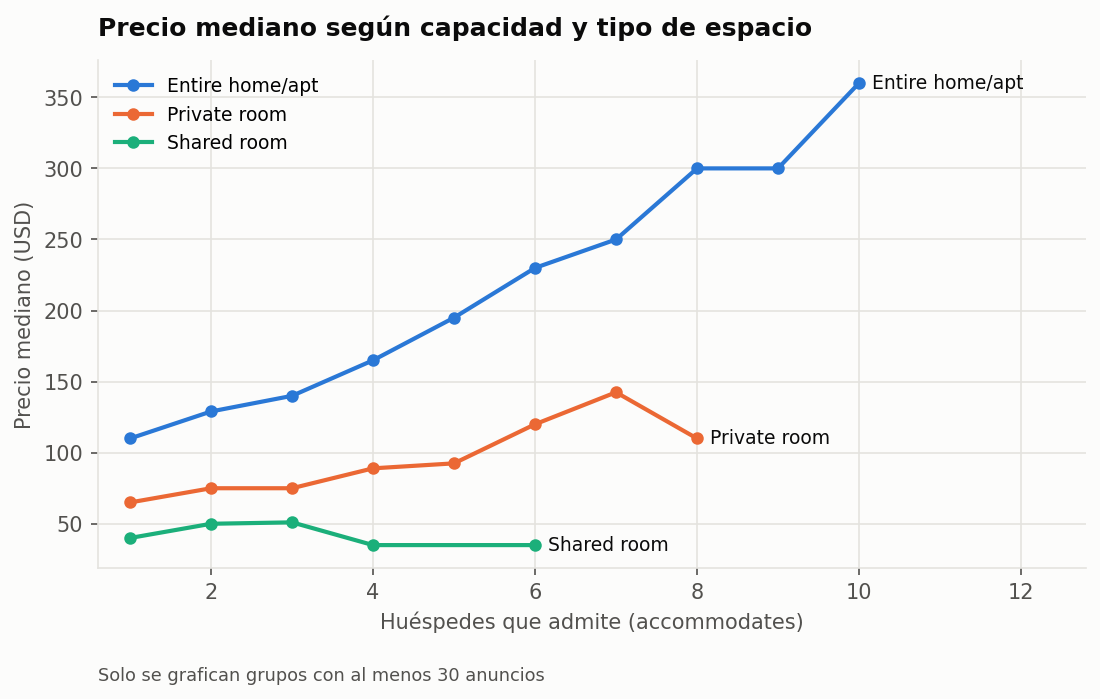

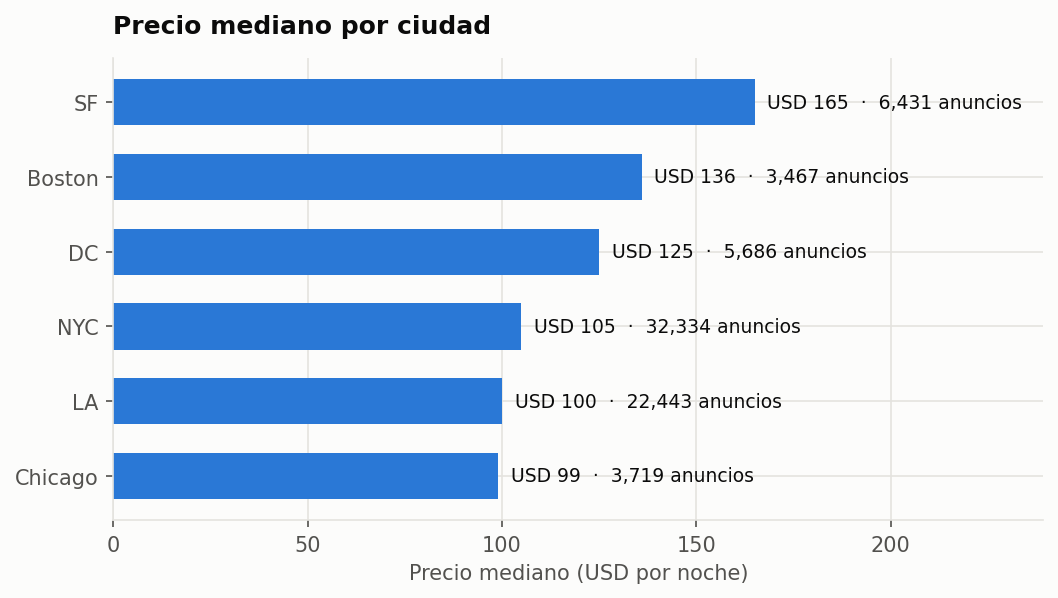

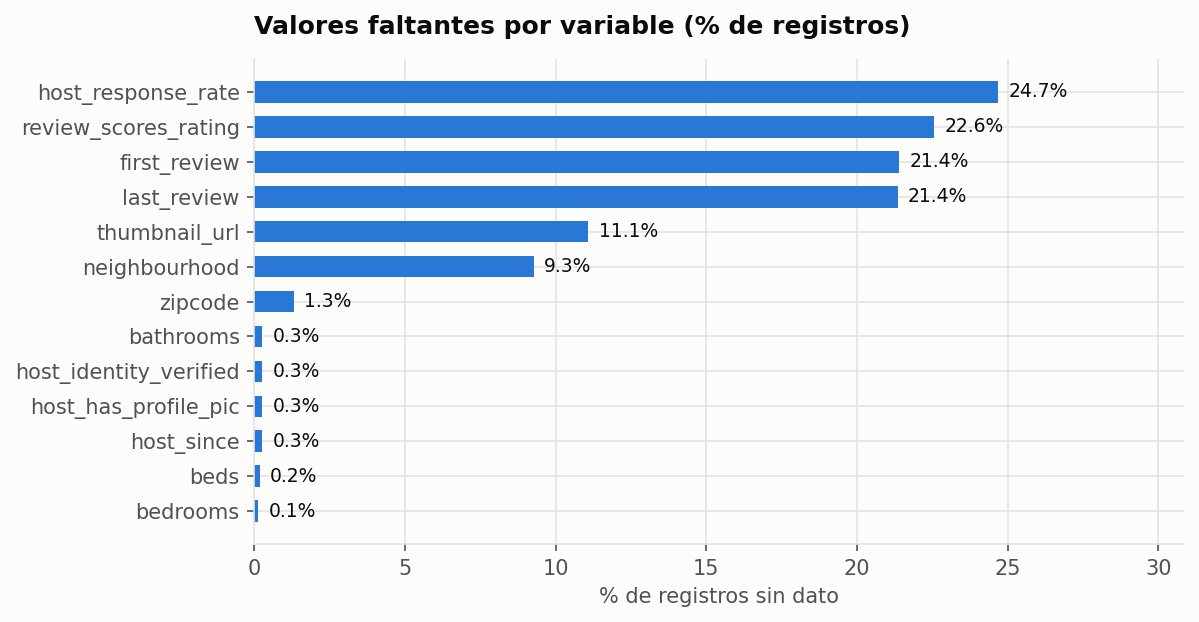

In [17]:
from IPython.display import Image, display

for path in report.figures:
    display(Image(filename=path))

## 9. Cierre

- La base queda descrita, no modificada.
- Los hallazgos y la interpretación de cada figura se desarrollan en el reporte
  `Actividad2_Reporte_EDA.docx`.
- La limpieza (imputación, normalización de formatos, codificación de
  categóricas y tratamiento de atípicos) corresponde a la Actividad 3.